# Notebook 2.6: RollingLDA codebook preparation

**Input:** outputs from notebook 2.4 (`outputs_rlda_fitting/`), checkpoints from 2.1 and 2.2

**Purpose:** produce all tabular and visual outputs needed to construct a topic codebook and assign dominant topics to documents.

Sections:
1. Setup: load all 2.4 outputs and shared helpers
2. Top-word tables: phi-ranked and relevance-ranked (lambda=0.4) per year
3. Representative documents: top 15 documents per topic by theta
4. Dominant topic assignment: threshold inspection and flagging
5. Topic stability export: per-chunk cosine self-similarity table
6. Per-topic word bar charts: phi vs relevance side by side

## 1. Setup

In [1]:
# Cell 1: Imports
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Cell 2: Paths and constants
CHECKPOINT_DIR = Path("checkpoints")
IN_DIR         = Path("outputs_rlda_fitting")
OUT_DIR        = Path("outputs_rlda_codebook")
OUT_DIR.mkdir(exist_ok=True)

DATE_COL   = "_date"
TOKEN_COL  = "_tokens_filtered"
DOC_ID_COL = "doc_id"
TEXT_COL   = "review"

N_TOP_WORDS  = 20
LAMBDA_VIS   = 0.4
N_REP_DOCS   = 10
N_CHUNK_WORDS = 15

In [3]:
# Cell 3: Load 2.4 outputs

df = pd.read_pickle(CHECKPOINT_DIR / "df_with_noun_tokens.pkl").copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df[df["noun_tokens"].apply(lambda x: isinstance(x, list))].copy()
df = df.sort_values(DATE_COL).reset_index(drop=True)

with open(CHECKPOINT_DIR / "chosen_vocab.pkl", "rb") as f:
    vc = pickle.load(f)
chosen_vocab_set = set(vc["chosen_vocab"]["kept_terms"])

df[TOKEN_COL] = df["noun_tokens"].apply(
    lambda toks: [t for t in toks if t.lower() in chosen_vocab_set]
)

if DOC_ID_COL not in df.columns:
    df[DOC_ID_COL] = [f"doc_{i}" for i in range(len(df))]

topic_word_counts_df = pd.read_csv(IN_DIR / "rollinglda_final_topic_word_counts.csv")
vocab  = [c for c in topic_word_counts_df.columns if c != "topic_id"]
topics = topic_word_counts_df[vocab].values          # K x V raw counts
phi    = topics / np.clip(topics.sum(axis=1, keepdims=True), 1e-12, None)  # K x V
K      = topics.shape[0]

doc_topic_df = pd.read_csv(IN_DIR / "rollinglda_doc_topic.csv")
doc_topic_df[DOC_ID_COL] = doc_topic_df[DOC_ID_COL].astype(str)
df[DOC_ID_COL]           = df[DOC_ID_COL].astype(str)

topic_cols = [f"topic_{k}" for k in range(K)]
df = df.merge(doc_topic_df[[DOC_ID_COL] + topic_cols], on=DOC_ID_COL, how="left")

missing = df[topic_cols].isna().any(axis=1).sum()
if missing > 0:
    raise ValueError(f"{missing} documents have no matching doc_topic row: check doc_id alignment")

doc_topic = df[topic_cols].values

# chunks_df is R compatible
chunks_df = pd.read_csv(IN_DIR / "rollinglda_chunks.csv")
chunks_df = chunks_df.rename(columns={"chunk.id": "chunk_id", "start.date": "chunk_start", "end.date": "chunk_end"})
chunks_df["chunk_start"] = pd.to_datetime(chunks_df["chunk_start"], unit="D", origin="1970-01-01")
chunks_df["chunk_end"]   = pd.to_datetime(chunks_df["chunk_end"],   unit="D", origin="1970-01-01")

df["_year"] = df[DATE_COL].dt.year
years = sorted(df["_year"].dropna().unique())

assert len(vocab) == phi.shape[1]
print(f"K={K}, V={len(vocab)}, D={len(df)}")
print(f"Date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Years: {years}")
print(f"Chunks: {len(chunks_df)}")

K=10, V=2871, D=6501
Date range: 1999-09-12 to 2014-06-12
Years: [np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014)]
Chunks: 12


In [4]:
# Cell 4: Shared helpers

vocab_index = {w: i for i, w in enumerate(vocab)}


def build_bow(frame: pd.DataFrame, tok_col: str, v_index: dict, v_size: int) -> np.ndarray:
    """Build a D x V count matrix from vocab-filtered token lists."""
    X = np.zeros((len(frame), v_size), dtype=np.int32)
    for d, toks in enumerate(frame[tok_col]):
        if not isinstance(toks, list):
            continue
        for tok in toks:
            i = v_index.get(str(tok).lower())
            if i is not None:
                X[d, i] += 1
    return X


def relevance_score(
    phi_k: np.ndarray,
    p_w: np.ndarray,
    lam: float = LAMBDA_VIS
) -> np.ndarray:
    """Relevance = lambda * log(phi_kw) + (1-lambda) * log(phi_kw / p_w), Sievert & Shirley 2014."""
    log_phi = np.log(np.clip(phi_k, 1e-12, None))
    log_lift = np.log(np.clip(phi_k, 1e-12, None)) - np.log(np.clip(p_w, 1e-12, None))
    return lam * log_phi + (1 - lam) * log_lift

## 2. Top-word tables

In [5]:
# Cell 5: Build full-corpus and per-year top-word tables

X_full = build_bow(df, TOKEN_COL, vocab_index, len(vocab))
p_w_full = X_full.sum(axis=0).astype(float)
p_w_full /= p_w_full.sum().clip(min=1e-12)

rows = []

# Full-corpus rows
for k in range(K):
    rel = relevance_score(phi[k], p_w_full)
    phi_order = phi[k].argsort()[::-1][:N_TOP_WORDS]
    rel_order = rel.argsort()[::-1][:N_TOP_WORDS]
    for rank, (pi, ri) in enumerate(zip(phi_order, rel_order), start=1):
        rows.append({
            "topic_id": k,
            "year": "all",
            "rank": rank,
            "word_phi": vocab[pi],
            "phi": float(phi[k, pi]),
            "word_relevance": vocab[ri],
            "relevance": float(rel[ri]),
        })

# Per-year rows
for yr in years:
    yr_mask = df["_year"].values == yr
    df_yr = df[yr_mask].reset_index(drop=True)
    X_yr = build_bow(df_yr, TOKEN_COL, vocab_index, len(vocab))
    p_w_yr = X_yr.sum(axis=0).astype(float)
    total_yr = p_w_yr.sum()
    if total_yr < 1:
        continue
    p_w_yr /= total_yr

    for k in range(K):
        rel = relevance_score(phi[k], p_w_yr)
        phi_order = phi[k].argsort()[::-1][:N_TOP_WORDS]
        rel_order = rel.argsort()[::-1][:N_TOP_WORDS]
        for rank, (pi, ri) in enumerate(zip(phi_order, rel_order), start=1):
            rows.append({
                "topic_id": k,
                "year": int(yr),
                "rank": rank,
                "word_phi": vocab[pi],
                "phi": float(phi[k, pi]),
                "word_relevance": vocab[ri],
                "relevance": float(rel[ri]),
            })

topic_words_df = pd.DataFrame(rows)
out_path = OUT_DIR / "codebook_topic_words.csv"
topic_words_df.to_csv(out_path, index=False)
print(f"Saved {len(topic_words_df)} rows to {out_path}")
topic_words_df[topic_words_df["year"] == "all"].head(40)

Saved 3400 rows to outputs_rlda_codebook/codebook_topic_words.csv


,topic_id,year,rank,word_phi,phi,word_relevance,relevance
0,0,all,1,skirt,0.015079,blazer,-1.467662
1,0,all,2,jacket,0.013984,white,-1.484864
2,0,all,3,leather,0.013017,masculine,-1.496438
3,0,all,4,white,0.011986,leather,-1.501076
4,0,all,5,short,0.007314,skirt,-1.514424
5,0,all,6,trouser,0.007250,trouser,-1.518418
6,0,all,7,coat,0.007153,pleated,-1.571194
7,0,all,8,shirt,0.007153,jacket,-1.616090
8,0,all,9,pant,0.007056,shirt,-1.647173
9,0,all,10,print,0.006283,couple,-1.751979


## 3. Representative documents

In [6]:
# Cell 6: Representative documents per topic

# Min topic proportion for a document to be considered form literature
THETA_MIN = 0.5

rep_rows = []
for k in range(K):
    theta_k = doc_topic[:, k]
    eligible = np.where(theta_k > THETA_MIN)[0]
    if len(eligible) == 0:
        print(f"Topic {k}: no documents above theta > {THETA_MIN}; lowering to 0.3")
        eligible = np.where(theta_k > 0.3)[0]
    top_idx = eligible[theta_k[eligible].argsort()[::-1][:N_REP_DOCS]]
    for rank, idx in enumerate(top_idx, start=1):
        row = {
            "topic_id": k,
            "rank": rank,
            DOC_ID_COL: df[DOC_ID_COL].iloc[idx],
            "year": int(df["_year"].iloc[idx]),
            "theta_dominant": float(theta_k[idx]),
        }

        snippet = str(df[TEXT_COL].iloc[idx])
        row["snippet"] = snippet[:400]
        rep_rows.append(row)

rep_docs_df = pd.DataFrame(rep_rows)
out_path = OUT_DIR / "codebook_representative_docs.csv"
rep_docs_df.to_csv(out_path, index=False)
print(f"Saved {len(rep_docs_df)} docs to {out_path}")
rep_docs_df.head(15)

Saved 100 docs to outputs_rlda_codebook/codebook_representative_docs.csv


,topic_id,rank,doc_id,year,theta_dominant,snippet
0,0,1,3057,2009,0.978571,"I always have a lot of references, Mulberry cr..."
1,0,2,3642,2010,0.978049,Get this: Diesel had a runway show and not a s...
2,0,3,5148,2012,0.975676,New York is out and Milan is in for Ports. Thi...
3,0,4,3189,2009,0.975000,Ferragamo announced this summer that it would ...
4,0,5,5739,2013,0.957971,There was nothing on the invitation that revea...
5,0,6,5808,2013,0.954762,Sister-and-brother design team Nicholas and Ch...
6,0,7,5126,2012,0.952500,This season's St. John presentation couldn't h...
7,0,8,3723,2010,0.934483,There were times today at Georgina Chapman and...
8,0,9,6180,2014,0.933898,Profligacy has never been Giorgio Armani 's ca...
9,0,10,5610,2013,0.932759,It's quite unusual to stumble onto a designer ...


## 4. Dominant topic assignment

Distribution of max(theta_dk):
 percentile  max_theta
          5   0.323729
         10   0.355385
         15   0.381081
         20   0.402222
         25   0.420968
         50   0.513333

Mean : 0.5362
Min  : 0.2040
Max  : 0.9908


/var/folders/_p/f1mg9b290kx6bf1ytjkd60qm0000gn/T/ipykernel_370/946266756.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


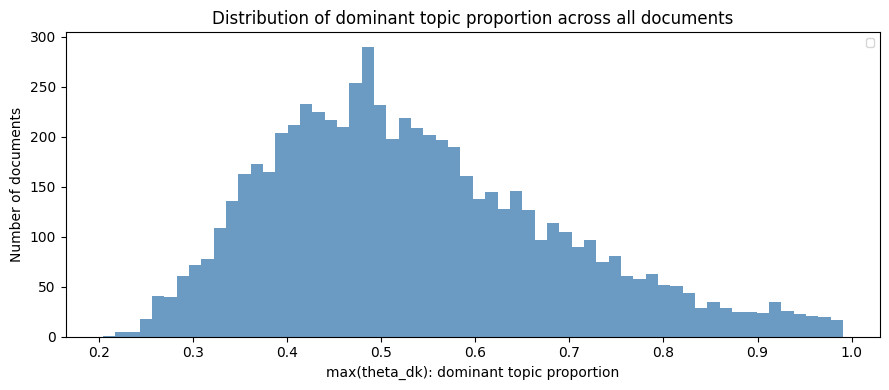

In [7]:
# Cell 7: Inspect max-theta distribution

max_theta = doc_topic.max(axis=1)

percentiles = [5, 10, 15, 20, 25, 50]
pct_table = pd.DataFrame({
    "percentile": percentiles,
    "max_theta": [float(np.percentile(max_theta, p)) for p in percentiles]
})
print("Distribution of max(theta_dk):")
print(pct_table.to_string(index=False))
print(f"\nMean : {max_theta.mean():.4f}")
print(f"Min  : {max_theta.min():.4f}")
print(f"Max  : {max_theta.max():.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(max_theta, bins=60, edgecolor="none", color="steelblue", alpha=0.8)
ax.set_xlabel("max(theta_dk): dominant topic proportion")
ax.set_ylabel("Number of documents")
ax.set_title("Distribution of dominant topic proportion across all documents")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "max_theta_distribution.png", dpi=150)
plt.show()

In [8]:
# Cell 8: Set threshold and assign dominant topics

dominant_topic = doc_topic.argmax(axis=1)

def assign_chunk(date):
    for _, row in chunks_df.iterrows():
        if row["chunk_start"] <= date <= row["chunk_end"]:
            return int(row["chunk_id"])
    return None

df["_chunk"] = df[DATE_COL].apply(assign_chunk)

assignments = pd.DataFrame({
    DOC_ID_COL: df[DOC_ID_COL].values,
    "year": df["_year"].values,
    "chunk": df["_chunk"].values,
    "dominant_topic": dominant_topic,
    "max_theta": max_theta,
})

out_path = OUT_DIR / "codebook_dominant_topic_assignments.csv"
assignments.to_csv(out_path, index=False)

print(f"Saved to {out_path}")

assignments["dominant_topic"].value_counts().sort_index()

Saved to outputs_rlda_codebook/codebook_dominant_topic_assignments.csv


dominant_topic
0    643
1    789
2    681
3    796
4    613
5    687
6    539
7    609
8    578
9    566
Name: count, dtype: int64

## 5. Topic stability export

Per-topic per-chunk cosine self-similarity (same values as the heatmap in 2.5), exported as a CSV for the codebook stability log.

Output: `codebook_topic_stability.csv`.

In [9]:
# Cell 9: Per-chunk phi, cosine self-similarity, and top words (single pass)


n_chunks = len(chunks_df)

# Build per-chunk phi approximation
chunk_phi = []
for _, cr in chunks_df.iterrows():
    mask = (
        (df[DATE_COL] >= cr["chunk_start"]) &
        (df[DATE_COL] <= cr["chunk_end"])
    ).values
    if mask.sum() == 0:
        chunk_phi.append(None)
        continue
    X_c  = build_bow(df[mask], TOKEN_COL, vocab_index, len(vocab))
    dt_c = doc_topic[mask]   # n_c x K
    phi_c = dt_c.T @ X_c    # K x V
    row_sums = phi_c.sum(axis=1, keepdims=True)
    phi_c = phi_c / np.clip(row_sums, 1e-12, None)
    chunk_phi.append(phi_c)

# Single pass over transitions
stab_rows       = []
chunk_word_rows = []

for c_idx in range(1, n_chunks):
    phi_prev = chunk_phi[c_idx - 1]
    phi_curr = chunk_phi[c_idx]
    if phi_prev is None or phi_curr is None:
        continue

    chunk_id    = int(chunks_df.iloc[c_idx]["chunk_id"])
    chunk_start = chunks_df.iloc[c_idx]["chunk_start"].date()
    chunk_end   = chunks_df.iloc[c_idx]["chunk_end"].date()

    # Chunk-local background marginals for relevance scoring
    mask_curr = (
        (df[DATE_COL] >= chunks_df.iloc[c_idx]["chunk_start"]) &
        (df[DATE_COL] <= chunks_df.iloc[c_idx]["chunk_end"])
    ).values
    X_curr    = build_bow(df[mask_curr], TOKEN_COL, vocab_index, len(vocab))
    p_w_chunk = X_curr.sum(axis=0).astype(float)
    total     = p_w_chunk.sum()
    if total < 1:
        continue
    p_w_chunk /= total

    for k in range(K):
        cos = float(cosine_similarity(
            phi_prev[k].reshape(1, -1),
            phi_curr[k].reshape(1, -1)
        )[0, 0])

        rel         = relevance_score(phi_curr[k], p_w_chunk)
        top_rel_idx = rel.argsort()[::-1][:N_CHUNK_WORDS]
        top_phi_idx = phi_curr[k].argsort()[::-1][:N_CHUNK_WORDS]

        stab_rows.append({
            "topic_id":         k,
            "chunk":            chunk_id,
            "cosine_similarity": cos,
        })
        chunk_word_rows.append({
            "chunk_id":      chunk_id,
            "chunk_start":   str(chunk_start),
            "chunk_end":     str(chunk_end),
            "topic_id":      k,
            "cosine_sim":    round(cos, 4),
            "top_words_phi": ", ".join(vocab[i] for i in top_phi_idx),
            "top_words_rel": ", ".join(vocab[i] for i in top_rel_idx),
        })

# Save stability
stab_df  = pd.DataFrame(stab_rows)
out_path = OUT_DIR / "codebook_topic_stability.csv"
stab_df.to_csv(out_path, index=False)
print(f"Saved {len(stab_df)} rows to {out_path}")

# Save chunk top words
chunk_words_df = pd.DataFrame(chunk_word_rows)
out_path       = OUT_DIR / "codebook_chunk_topic_words.csv"
chunk_words_df.to_csv(out_path, index=False)
print(f"\nSaved {len(chunk_words_df)} rows to {out_path}")

Saved 110 rows to outputs_rlda_codebook/codebook_topic_stability.csv

Saved 110 rows to outputs_rlda_codebook/codebook_chunk_topic_words.csv


In [10]:
# Cell 10: inspect less stable chunks per topic

stats = stab_df.groupby("topic_id")["cosine_similarity"].agg(["mean", "std"])
print(stats.round(3))

overall_mean = stab_df["cosine_similarity"].mean()
overall_std  = stab_df["cosine_similarity"].std()
threshold    = overall_mean - 2 * overall_std

print(f"\nthreshold (mean - 2 SD): {threshold:.3f}")
print(stab_df[stab_df["cosine_similarity"] < threshold][["topic_id", "chunk", "cosine_similarity"]].round(3).to_string(index=False))

           mean    std
topic_id              
0         0.889  0.027
1         0.892  0.026
2         0.882  0.031
3         0.908  0.018
4         0.875  0.022
5         0.876  0.028
6         0.886  0.022
7         0.872  0.032
8         0.878  0.041
9         0.892  0.025

threshold (mean - 2 SD): 0.828
 topic_id  chunk  cosine_similarity
        2      1              0.825
        7      2              0.820
        5     11              0.826
        8     11              0.805


In [11]:
# low similiarity chunks for event detection

low_sim = chunk_words_df[chunk_words_df["cosine_sim"] < threshold].sort_values("cosine_sim")
print(f"{len(low_sim)} topic-chunk pairs below threshold:")
print(low_sim[["chunk_id", "chunk_start", "topic_id", "cosine_sim", "top_words_rel"]].to_string(index=False))

low_sim.to_csv(OUT_DIR / "codebook_lower_similarity_chunks.csv", index=False)

4 topic-chunk pairs below threshold:
 chunk_id chunk_start  topic_id  cosine_sim                                                                                                                                top_words_rel
       11  2014-01-30         8      0.8052                   tweedy, remote, bridge, winter, pale, formal, unusual, patent, print, diverse, business, pleasure, coat, cashmere, portion
        2  2005-02-03         7      0.8201                           denim, street, legging, hoodie, graphic, white, applause, big, tennis, kitsch, fun, energy, seasonal, bright, team
        1  2004-01-18         2      0.8248                              party, print, jean, chiffon, fun, clingy, sugar, ambition, fruit, necklace, accessory, purse, lamé, great, pool
       11  2014-01-30         5      0.8259 culture, supermarket, life, past, mass, obsession, extravagant, movie, catwalk, ongoing, candy, exhibition, theatrical, ground, presentation


## 7. Per-topic word bar charts

One figure per topic: phi-ranked top 15 (left) and relevance-ranked top 15 at lambda=0.4 (right), using full-corpus background.

Use these to write codebook label definitions and to identify words that shift rank significantly between the two orderings: those are the words that are common corpus-wide but genuinely discriminative for the topic.

All figures saved to `outputs_rlda_codebook/`.

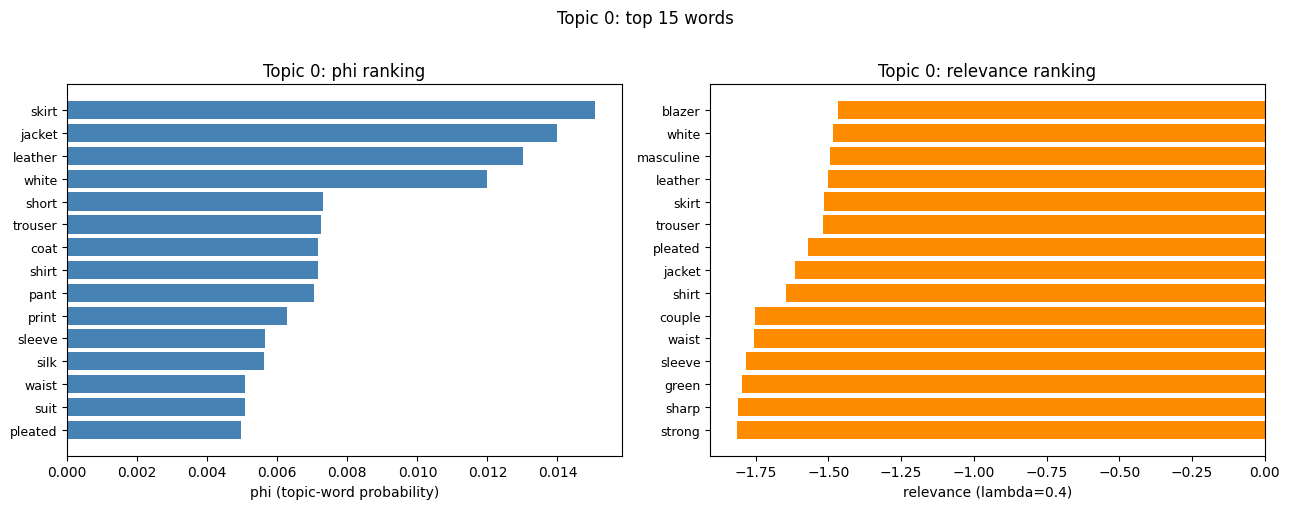

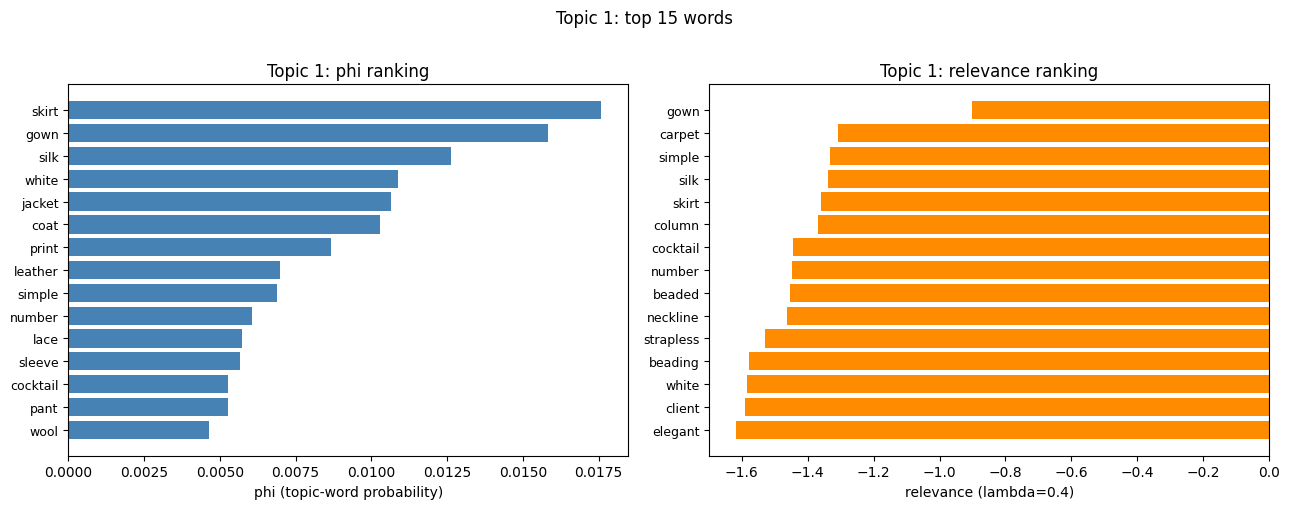

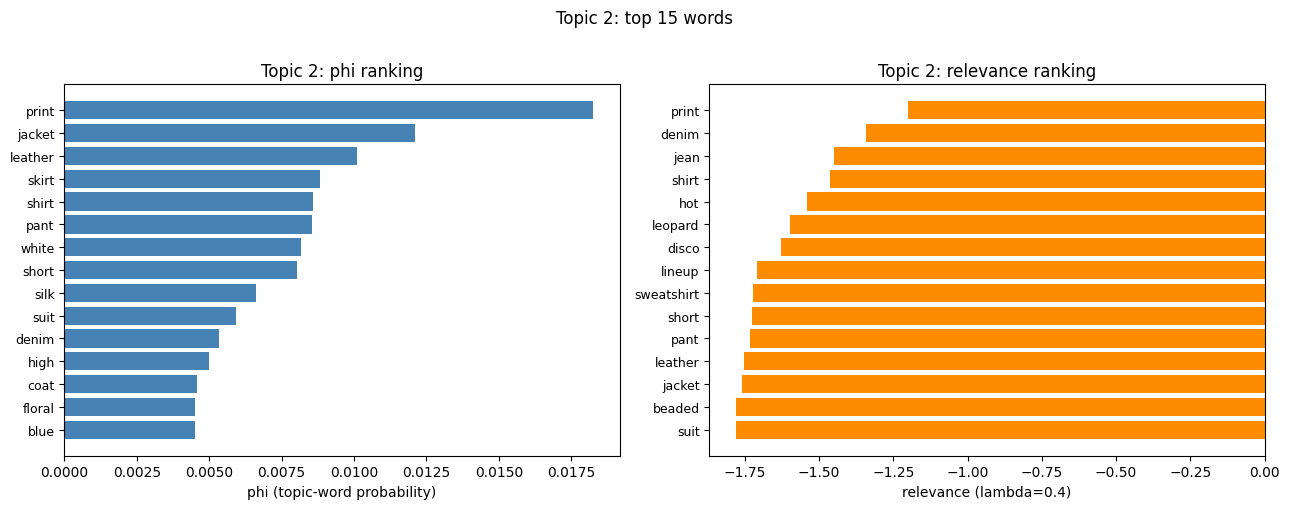

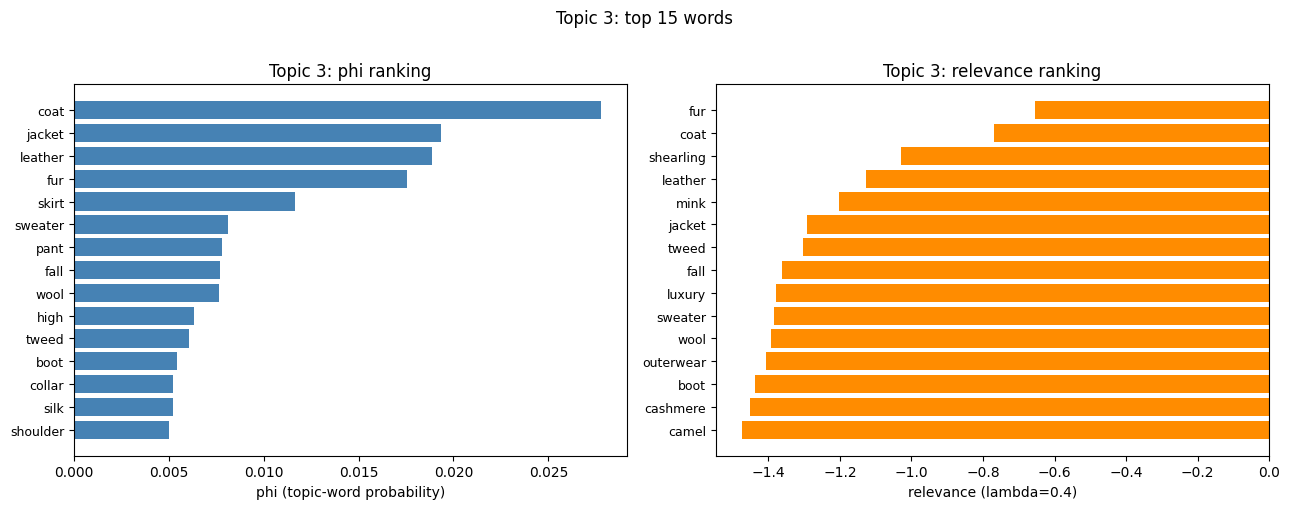

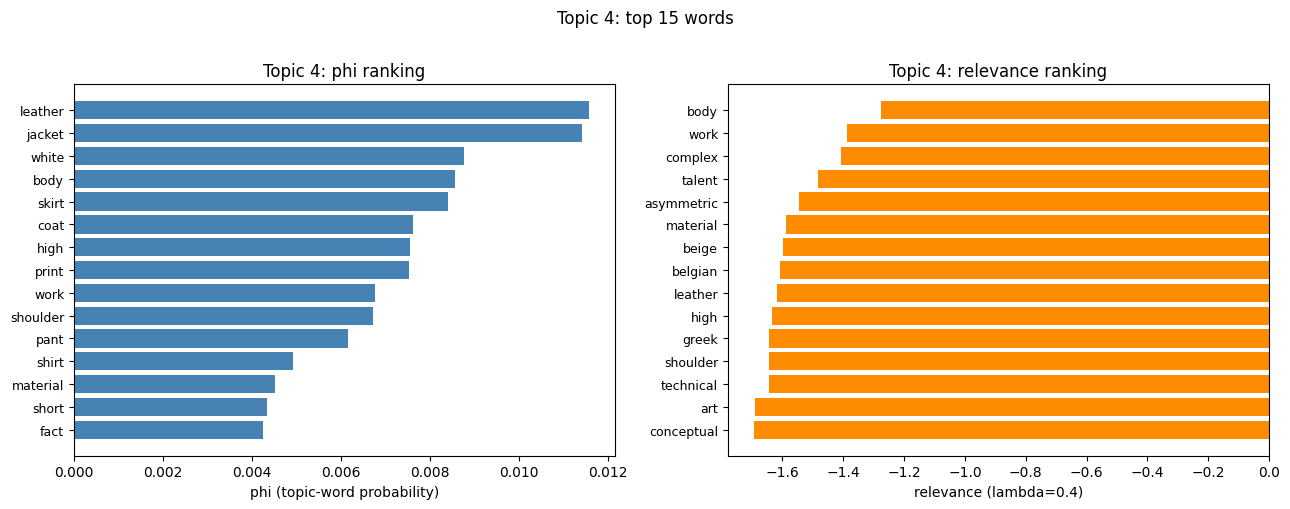

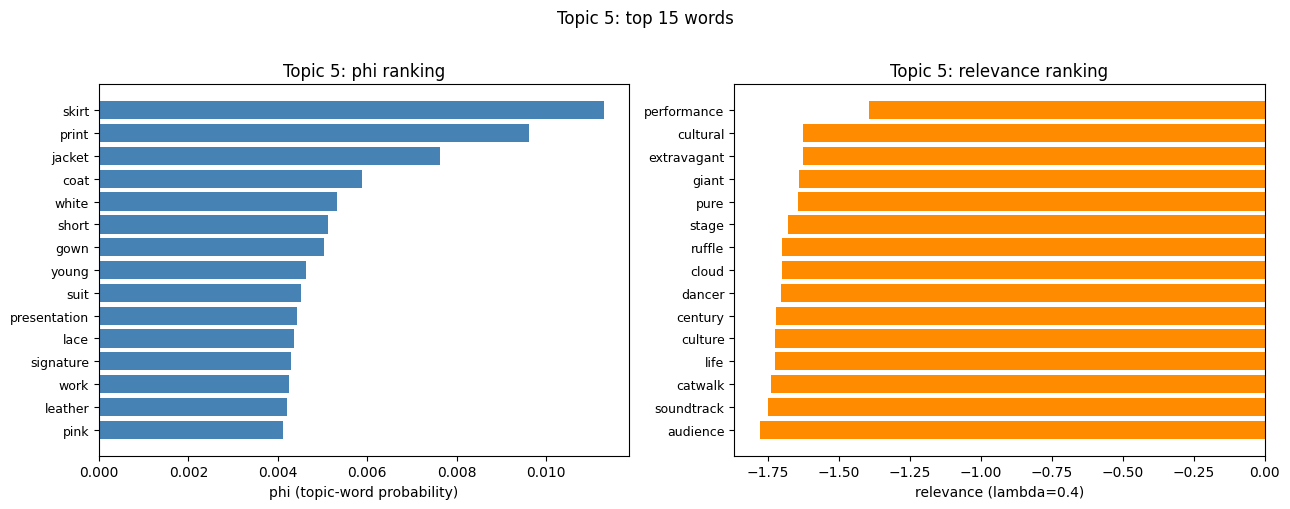

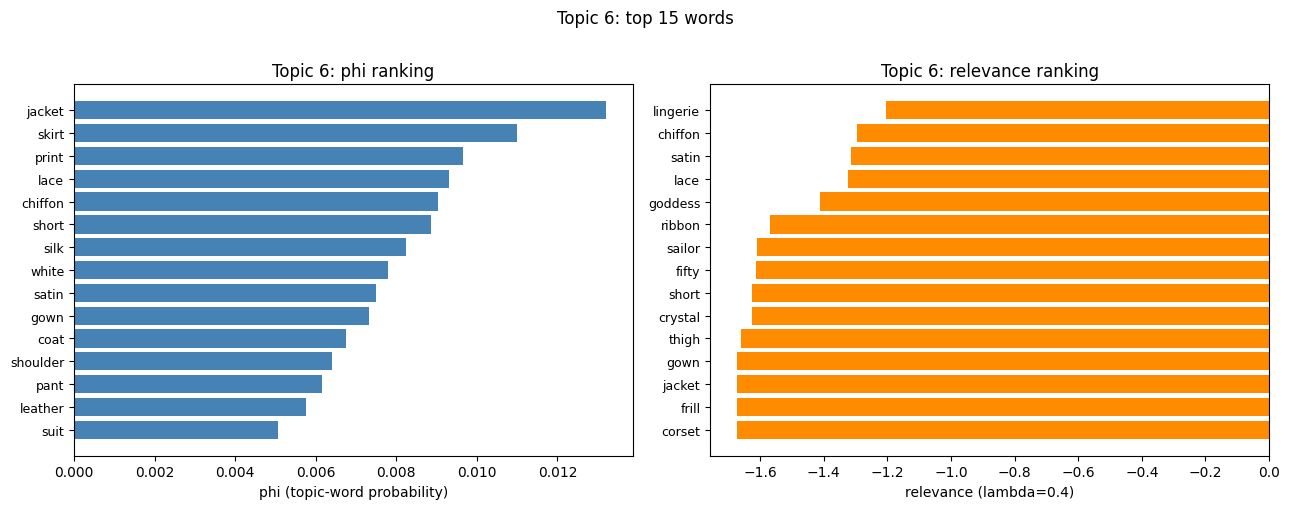

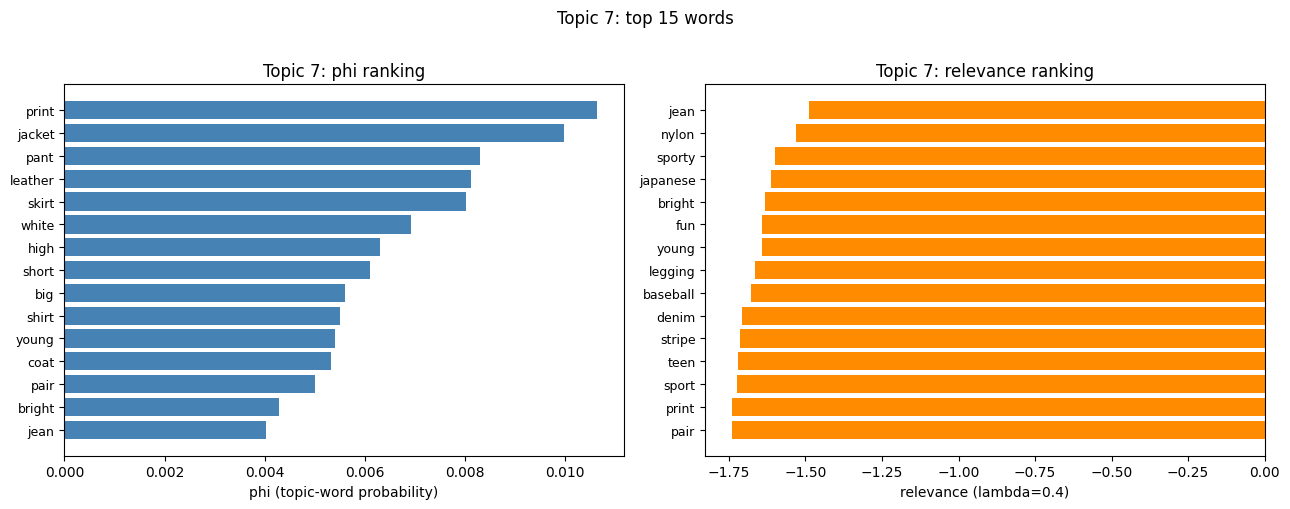

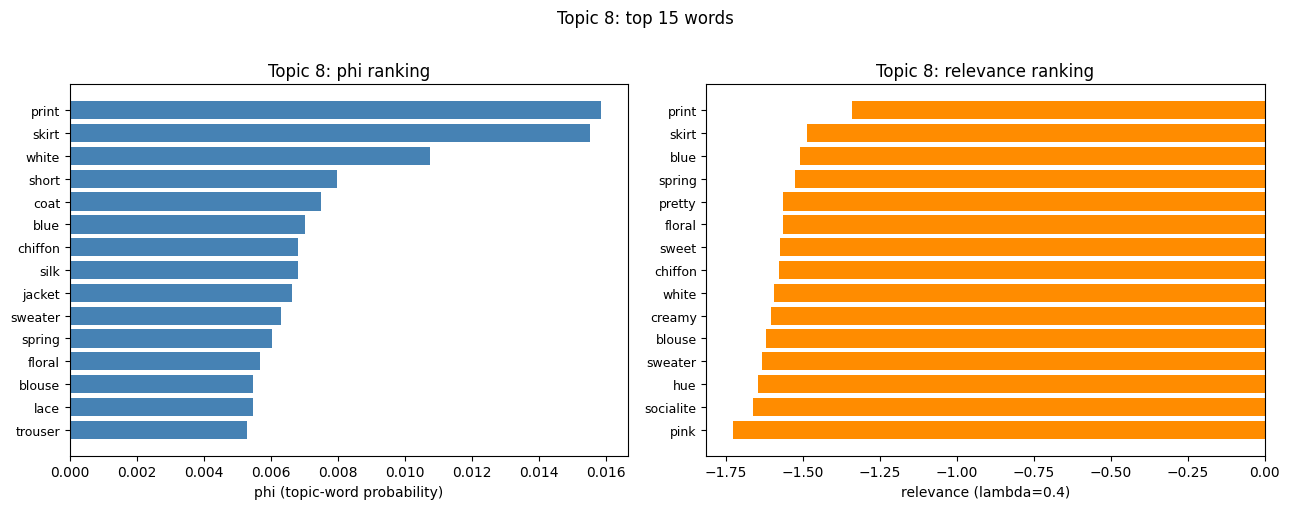

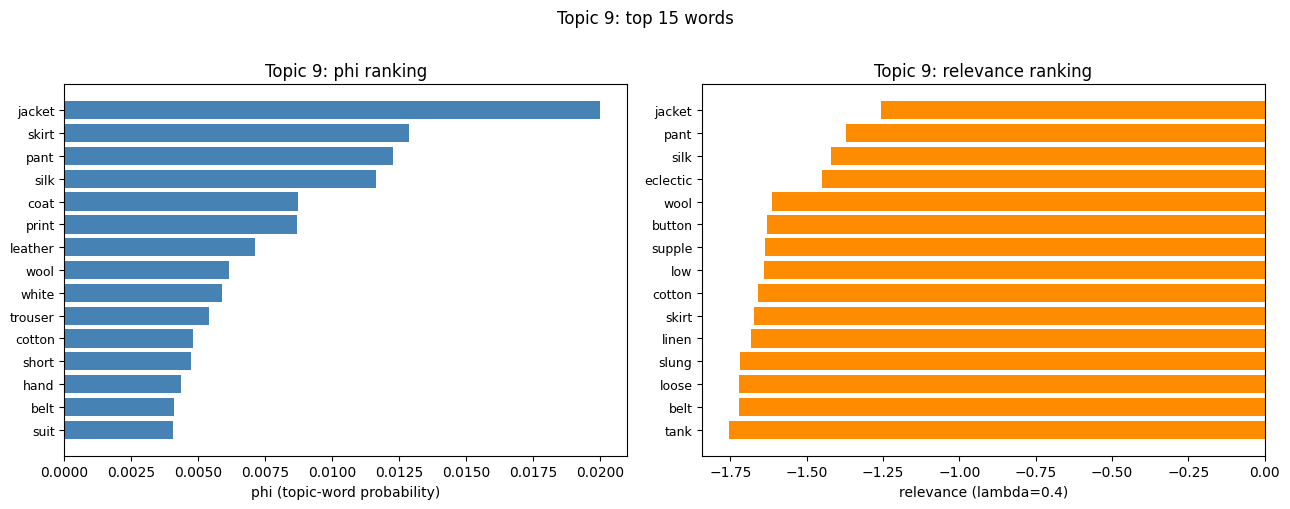

Saved 10 word bar charts to outputs_rlda_codebook


In [12]:
# Cell 12: Per-topic side-by-side bar charts (phi vs relevance)

N_BAR = 15

for k in range(K):
    rel = relevance_score(phi[k], p_w_full)

    phi_idx = phi[k].argsort()[::-1][:N_BAR]
    rel_idx = rel.argsort()[::-1][:N_BAR]

    phi_words  = [vocab[i] for i in phi_idx]
    phi_vals   = [phi[k, i] for i in phi_idx]
    rel_words  = [vocab[i] for i in rel_idx]
    rel_vals   = [rel[i] for i in rel_idx]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].barh(range(N_BAR), phi_vals[::-1], color="steelblue", edgecolor="none")
    axes[0].set_yticks(range(N_BAR))
    axes[0].set_yticklabels(phi_words[::-1], fontsize=9)
    axes[0].set_xlabel("phi (topic-word probability)")
    axes[0].set_title(f"Topic {k}: phi ranking")

    axes[1].barh(range(N_BAR), rel_vals[::-1], color="darkorange", edgecolor="none")
    axes[1].set_yticks(range(N_BAR))
    axes[1].set_yticklabels(rel_words[::-1], fontsize=9)
    axes[1].set_xlabel(f"relevance (lambda={LAMBDA_VIS})")
    axes[1].set_title(f"Topic {k}: relevance ranking")

    fig.suptitle(f"Topic {k}: top {N_BAR} words", fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"topic_{k}_words.png", dpi=150)
    plt.show()

print(f"Saved {K} word bar charts to {OUT_DIR}")